# 14 — Human–Model Blind Alignment

**Core question**: When both humans and models answer VQA questions without seeing an image, do they *imagine the same things*? Which architectures produce blind answers most similar to human blind answers, and on which question types do they diverge?

**Framing**: Accuracy against ground truth is expected (training leakage). The more interesting question is whether model blind priors are *aligned with human blind priors*, measured by direct human–model answer similarity against the human–human ceiling.

**This notebook**:
1. Per-question HM agreement profiles by model group (all metrics vs HH baseline)
2. HM agreement by question operation type and entity type — where do imaginations align?
3. Distance from HH ceiling: per-question gap to human–human agreement
4. Per-question analysis: which questions show strongest/weakest human–model alignment?
5. Multi-metric consistency check (style vs content)
6. Supplementary: within-group metric–accuracy correlation

In [ ]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats

ROOT = Path('../../').resolve()
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / 'analysis'))
from figures.helpers import save_fig

from utils.constants import GROUP_COLORS, GROUP_ORDER
from config import MODELS_7B

EXPORTS = ROOT / 'analysis/session2/exports'
VARIANT = 'C'
CONDITION = 'inst_blind'  # primary; repeat for blind
MODEL_SCOPE = '7/8B matched subset'
_7b_set = set(MODELS_7B)

OUT_DIR = ROOT / 'figures/supplementary/sbert_gap_7b'
OUT_DIR.mkdir(parents=True, exist_ok=True)


## 1. Load data

In [2]:
blind_df      = pd.read_csv(EXPORTS / 'responses_model_blind.csv')
inst_blind_df = pd.read_csv(EXPORTS / 'responses_model_inst_blind.csv')
human_df      = pd.read_csv(EXPORTS / 'responses_human.csv')
pair_cache    = pd.read_parquet(EXPORTS / 'pair_cache_raw.parquet')

# Restrict to variant C
blind_vC      = blind_df[blind_df['variant'] == VARIANT].copy()
inst_blind_vC = inst_blind_df[inst_blind_df['variant'] == VARIANT].copy()
human_vC      = human_df[human_df['variant'] == VARIANT].copy()
pc_vC         = pair_cache[pair_cache['variant'] == VARIANT].copy()

# Restrict to matched 7/8B model subset for this main notebook
blind_vC      = blind_vC[blind_vC['model'].isin(_7b_set)].copy()
inst_blind_vC = inst_blind_vC[inst_blind_vC['model'].isin(_7b_set)].copy()
# Keep HH pairs intact; filter HM pairs to 7/8B models
pc_vC         = pc_vC[(pc_vC['pair_type'] != 'HM') | (pc_vC['subject_2'].isin(_7b_set))].copy()

print(f'Model scope: {MODEL_SCOPE}')
print(f'Model blind vC: {len(blind_vC)} rows, {blind_vC["model"].nunique()} models')
print(f'Model inst_blind vC: {len(inst_blind_vC)} rows')
print(f'Human vC: {len(human_vC)} rows, {human_vC["participant"].nunique()} participants')
print(f'Pair cache vC: {len(pc_vC)} pairs')


Model scope: 7/8B matched subset
Model blind vC: 1803 rows, 16 models
Model inst_blind vC: 1708 rows
Human vC: 4520 rows, 40 participants
Pair cache vC: 179727 pairs


## 2. Per-question accuracy: model vs human

`responses_model_*.csv` already has `human_avg_acc` (mean human accuracy over the study participants) and `accuracy` (model accuracy) per question × model row.

In [3]:
def make_acc_df(df, condition_label):
    """Per question × model: accuracy gap = model_acc - human_avg_acc."""
    d = df.copy()
    d['acc_gap'] = d['accuracy'] - d['human_avg_acc']
    d['condition'] = condition_label
    return d

blind_acc      = make_acc_df(blind_vC, 'blind')
inst_blind_acc = make_acc_df(inst_blind_vC, 'inst_blind')
acc_df = pd.concat([blind_acc, inst_blind_acc], ignore_index=True)

# Summary by model × condition
gap_summary = acc_df.groupby(['model_group', 'model', 'condition']).agg(
    mean_model_acc=('accuracy', 'mean'),
    mean_human_acc=('human_avg_acc', 'mean'),
    mean_acc_gap=('acc_gap', 'mean'),
    n_questions=('question_id', 'nunique')
).reset_index()

# Show top gaps
inst_gaps = gap_summary[gap_summary['condition'] == 'inst_blind'].sort_values('mean_acc_gap', ascending=False)
print('\nInst-blind accuracy gap (model − human), top models:')
print(inst_gaps[['model_group', 'model', 'mean_model_acc', 'mean_human_acc', 'mean_acc_gap']].head(20).to_string(index=False))


Inst-blind accuracy gap (model − human), top models:
           model_group               model  mean_model_acc  mean_human_acc  mean_acc_gap
                   VLM       LLaVA-Mistral        0.536873        0.262242      0.274631
  VLM backbone decoder      LLaVA-1.5 (LM)        0.536873        0.262242      0.274631
  VLM backbone decoder  LLaVA-Mistral (LM)        0.536873        0.262242      0.274631
                   VLM        LLaVA-Vicuna        0.516224        0.262242      0.253982
                   VLM         Qwen3-VL-8B        0.473214        0.262054      0.211161
                   VLM        LLaVA-1.5-7B        0.471976        0.262242      0.209735
  VLM backbone decoder   LLaVA-Vicuna (LM)        0.445428        0.262242      0.183186
  VLM backbone decoder    Qwen3-VL-8B (LM)        0.421829        0.262242      0.159587
  VLM backbone decoder    InternVL-8B (LM)        0.398230        0.262242      0.135988
                   VLM         InternVL-8B        0.3716

In [4]:
# Group-level summary
grp_gap = acc_df.groupby(['model_group', 'condition']).agg(
    mean_model_acc=('accuracy', 'mean'),
    mean_human_acc=('human_avg_acc', 'mean'),
    mean_acc_gap=('acc_gap', 'mean'),
).reset_index()

print('Group-level accuracy gap:')
print(grp_gap.sort_values(['condition','mean_acc_gap'], ascending=[True, False]).to_string(index=False))

Group-level accuracy gap:
           model_group  condition  mean_model_acc  mean_human_acc  mean_acc_gap
                   VLM      blind        0.489676        0.262242      0.227434
  VLM backbone decoder      blind        0.431268        0.262242      0.169027
standalone LLM (think)      blind        0.309524        0.264583      0.044940
        standalone LLM      blind        0.160428        0.262745     -0.102317
                   VLM inst_blind        0.473995        0.262204      0.211791
  VLM backbone decoder inst_blind        0.467847        0.262242      0.205605
standalone LLM (think) inst_blind        0.271386        0.262242      0.009145
        standalone LLM inst_blind        0.190987        0.261427     -0.070440


## 3. Per-question SBERT: model answer ↔ human answer (HM pairs)

In [5]:
# HM pairs: subject_1=human, subject_2=model
hm = pc_vC[pc_vC['pair_type'] == 'HM'].copy()

# Mean SBERT per question × model (averaging over all human raters paired with this model)
hm_sbert = hm.groupby(['question_id', 'subject_2', 'subject_group_2']).agg(
    mean_sbert=('sbert_score', 'mean'),
    mean_chrf=('chrf_score', 'mean'),
    mean_exact=('exact_score', 'mean'),
    n_pairs=('sbert_score', 'count')
).reset_index().rename(columns={'subject_2': 'model', 'subject_group_2': 'model_group'})

print(f'HM SBERT table: {len(hm_sbert)} rows ({hm_sbert["model"].nunique()} models × {hm_sbert["question_id"].nunique()} questions)')

HM SBERT table: 1319 rows (15 models × 88 questions)


## 4. Join accuracy gap + SBERT per question × model

In [6]:
# Join inst_blind accuracy with HM SBERT
joined = inst_blind_acc.merge(
    hm_sbert[['question_id', 'model', 'mean_sbert', 'mean_chrf', 'mean_exact']],
    on=['question_id', 'model'],
    how='inner'
)
print(f'Joined: {len(joined)} rows')

# Also compute question-level: mean across models in each group
q_group = joined.groupby(['question_id', 'model_group', 'ent', 'op', 'question_en', 'gt', 'human_avg_acc']).agg(
    mean_model_acc=('accuracy', 'mean'),
    mean_acc_gap=('acc_gap', 'mean'),
    mean_sbert=('mean_sbert', 'mean'),
    mean_chrf=('mean_chrf', 'mean'),
).reset_index()

print(q_group['model_group'].value_counts())

Joined: 1319 rows
model_group
VLM                       88
VLM backbone decoder      88
standalone LLM            88
standalone LLM (think)    88
Name: count, dtype: int64


## 5. Scatter: accuracy gap vs SBERT, per model group

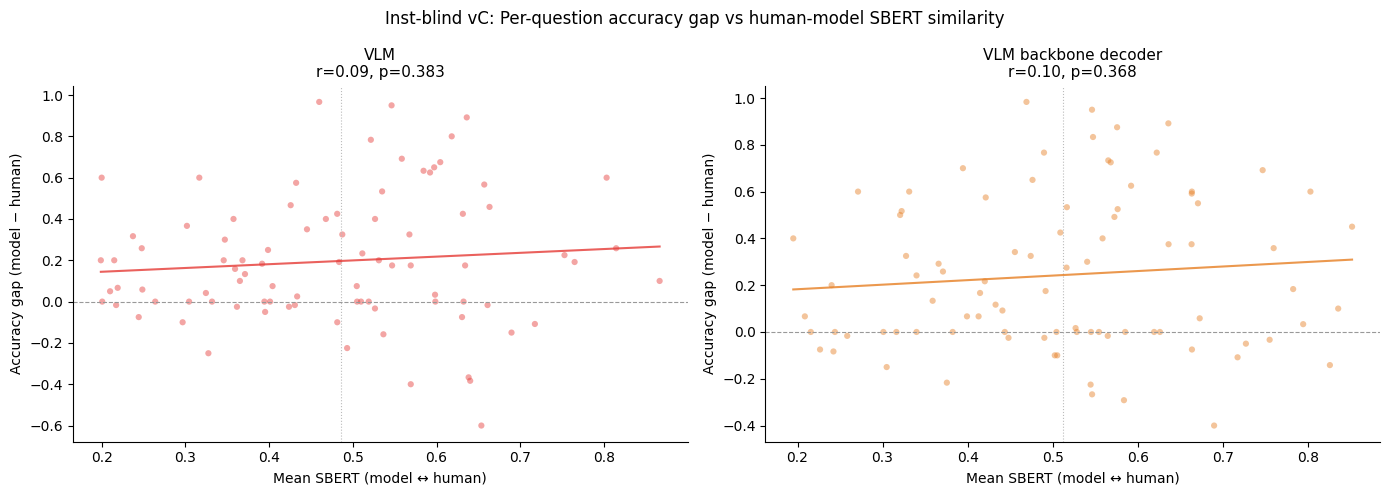

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, grp in zip(axes, ['VLM', 'VLM backbone decoder']):
    sub = q_group[q_group['model_group'] == grp]
    color = GROUP_COLORS.get(grp, '#888')
    ax.scatter(sub['mean_sbert'], sub['mean_acc_gap'],
               alpha=0.45, s=20, color=color, edgecolors='none')
    # reference lines
    ax.axhline(0, color='#999', lw=0.8, ls='--')
    ax.axvline(sub['mean_sbert'].median(), color='#bbb', lw=0.8, ls=':')
    # regression
    x, y = sub['mean_sbert'].values, sub['mean_acc_gap'].values
    mask = ~(np.isnan(x) | np.isnan(y))
    if mask.sum() > 5:
        r, p = stats.pearsonr(x[mask], y[mask])
        m, b = np.polyfit(x[mask], y[mask], 1)
        xr = np.linspace(x[mask].min(), x[mask].max(), 100)
        ax.plot(xr, m*xr + b, color=color, lw=1.5, alpha=0.8)
        ax.set_title(f'{grp}\nr={r:.2f}, p={p:.3f}', fontsize=11)
    ax.set_xlabel('Mean SBERT (model ↔ human)', fontsize=10)
    ax.set_ylabel('Accuracy gap (model − human)', fontsize=10)
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('Inst-blind vC: Per-question accuracy gap vs human-model SBERT similarity', fontsize=12)
plt.tight_layout()
plt.show()

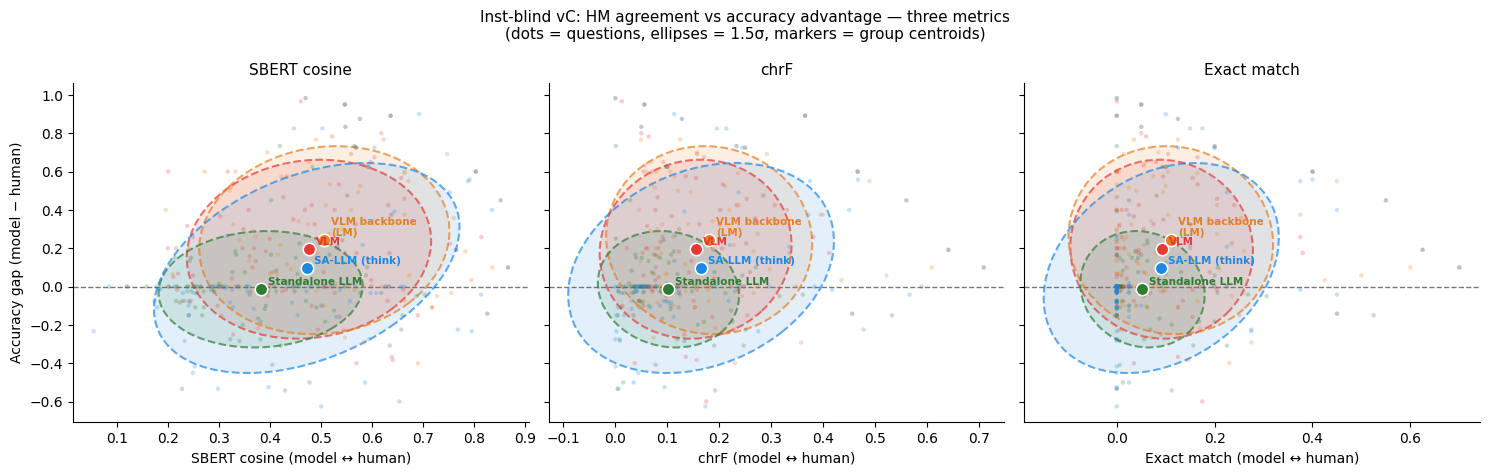

In [8]:
# ── Cluster scatter: 7/8B groups, three metrics side by side ───────────────────
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms

def confidence_ellipse(x, y, ax, n_std=1.5, fill=True, **kwargs):
    if len(x) < 3: return
    cov = np.cov(x, y)
    pearson = cov[0, 1] / np.sqrt(cov[0, 0] * cov[1, 1])
    ell_rx = np.sqrt(1 + pearson); ell_ry = np.sqrt(1 - pearson)
    kw = dict(width=ell_rx * 2, height=ell_ry * 2)
    if not fill: kw['fill'] = False
    ellipse = Ellipse((0, 0), **kw, **kwargs)
    sx = np.sqrt(cov[0, 0]) * n_std; sy = np.sqrt(cov[1, 1]) * n_std
    t = (transforms.Affine2D().rotate_deg(45).scale(sx, sy)
         .translate(np.mean(x), np.mean(y)))
    ellipse.set_transform(t + ax.transData)
    ax.add_patch(ellipse)

# Join all three HM metrics
hm_all = pc_vC[pc_vC['pair_type'] == 'HM'].copy()
hm_agg = (hm_all.groupby(['question_id', 'subject_2'])
          [['sbert_score', 'chrf_score', 'exact_score']].mean().reset_index()
          .rename(columns={'subject_2': 'model'}))
joined_all = inst_blind_acc.merge(hm_agg, on=['question_id', 'model'], how='inner')
q_all = (joined_all.groupby(['question_id', 'model_group'])
         [['acc_gap', 'sbert_score', 'chrf_score', 'exact_score']].mean().reset_index())

METRICS = [
    ('sbert_score', 'SBERT cosine'),
    ('chrf_score',  'chrF'),
    ('exact_score', 'Exact match'),
]
GROUP_LABEL = {
    'VLM':                    'VLM',
    'VLM backbone decoder':   'VLM backbone\n(LM)',
    'standalone LLM':         'Standalone LLM',
    'standalone LLM (think)': 'SA-LLM (think)',
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), sharey=True)

for ax, (metric_col, metric_name) in zip(axes, METRICS):
    for grp in GROUP_ORDER:
        sub = q_all[q_all['model_group'] == grp]
        if sub.empty: continue
        x = sub[metric_col].values; y = sub['acc_gap'].values
        mask = ~(np.isnan(x) | np.isnan(y)); x, y = x[mask], y[mask]
        color = GROUP_COLORS.get(grp, '#888')
        label = GROUP_LABEL.get(grp, grp)
        confidence_ellipse(x, y, ax, n_std=1.5, fill=True,
                           alpha=0.12, facecolor=color, zorder=1)
        confidence_ellipse(x, y, ax, n_std=1.5, fill=False,
                           alpha=0.70, edgecolor=color,
                           linewidth=1.5, linestyle='--', zorder=2)
        ax.scatter(x, y, alpha=0.25, s=10, color=color, edgecolors='none', zorder=3)
        ax.scatter(np.mean(x), np.mean(y), s=80, color=color, zorder=5,
                   edgecolors='white', linewidths=1.1)
        ax.annotate(label, (np.mean(x), np.mean(y)),
                    xytext=(5, 3), textcoords='offset points',
                    fontsize=7.5, color=color, fontweight='bold', zorder=6)
        r, p = stats.pearsonr(x, y)
    ax.axhline(0, color='#777', lw=1.0, ls='--', zorder=0)
    ax.set_xlabel(f'{metric_name} (model ↔ human)', fontsize=10)
    ax.set_title(metric_name, fontsize=11)
    ax.spines[['top', 'right']].set_visible(False)

axes[0].set_ylabel('Accuracy gap (model − human)', fontsize=10)
fig.suptitle('Inst-blind vC: HM agreement vs accuracy advantage — three metrics\n'
             '(dots = questions, ellipses = 1.5σ, markers = group centroids)',
             fontsize=11)
plt.tight_layout()
plt.show()

In [9]:
# AUTOGEN: question-level corr printout
# ── 5b. Question-level correlation: HM agreement vs accuracy gap (from q_all) ──
from scipy.stats import pearsonr

Q_METRICS = [('sbert_score', 'SBERT'), ('chrf_score', 'chrF'), ('exact_score', 'Exact')]
print('Question-level Pearson r: agreement metric vs accuracy gap (q_all)')
for grp in GROUP_ORDER:
    sub = q_all[q_all['model_group'] == grp]
    print(f'\n[{grp}] n={len(sub)}')
    for mcol, mlabel in Q_METRICS:
        valid = sub.dropna(subset=[mcol, 'acc_gap'])
        if len(valid) < 3:
            print(f'  {mlabel:<8} r=NA  p=NA (n={len(valid)})')
            continue
        r, p = pearsonr(valid[mcol], valid['acc_gap'])
        print(f'  {mlabel:<8} r={r:+.3f}  p={p:.4g}')


Question-level Pearson r: agreement metric vs accuracy gap (q_all)

[VLM] n=88
  SBERT    r=+0.094  p=0.383
  chrF     r=+0.048  p=0.6587
  Exact    r=-0.023  p=0.8338

[VLM backbone decoder] n=88
  SBERT    r=+0.097  p=0.3681
  chrF     r=-0.040  p=0.7131
  Exact    r=-0.044  p=0.6825

[standalone LLM] n=88
  SBERT    r=+0.062  p=0.5687
  chrF     r=-0.107  p=0.3189
  Exact    r=-0.101  p=0.3506

[standalone LLM (think)] n=88
  SBERT    r=+0.388  p=0.0001861
  chrF     r=+0.259  p=0.01478
  Exact    r=+0.289  p=0.006261


## 6. Model-level summary: SBERT vs accuracy gap trade-off

Reproduces the 2D view that prompted this notebook — which models are high-SBERT + high-gap?

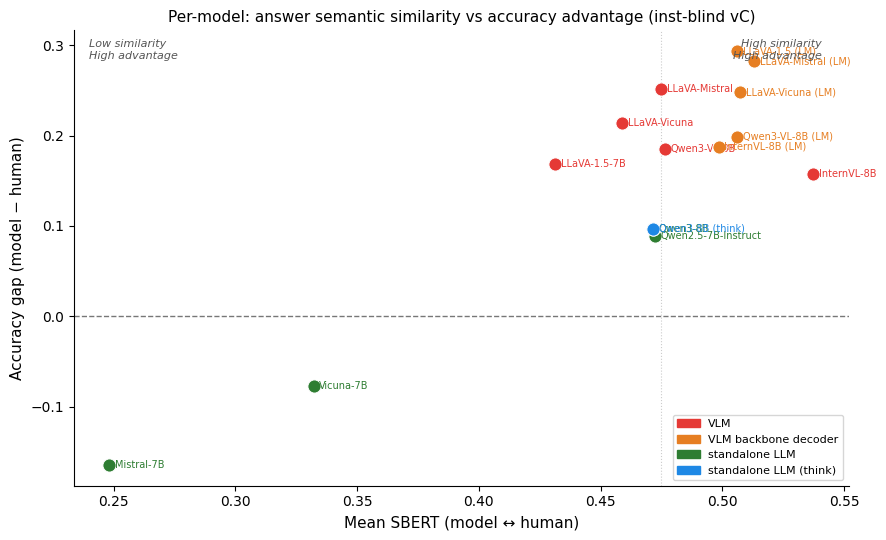


Model summary:
           model_group               model  mean_sbert  mean_model_acc  mean_human_acc  mean_acc_gap
  VLM backbone decoder      LLaVA-1.5 (LM)    0.506069        0.458333        0.164678      0.293655
  VLM backbone decoder  LLaVA-Mistral (LM)    0.513030        0.446970        0.164678      0.282292
                   VLM       LLaVA-Mistral    0.474982        0.416667        0.164678      0.251989
  VLM backbone decoder   LLaVA-Vicuna (LM)    0.507316        0.412879        0.164678      0.248201
                   VLM        LLaVA-Vicuna    0.458890        0.378788        0.164678      0.214110
  VLM backbone decoder    Qwen3-VL-8B (LM)    0.506169        0.363636        0.164678      0.198958
  VLM backbone decoder    InternVL-8B (LM)    0.498449        0.352273        0.164678      0.187595
                   VLM         Qwen3-VL-8B    0.476355        0.348659        0.163314      0.185345
                   VLM        LLaVA-1.5-7B    0.431387        0.333333     

In [10]:
# Per-model summary
model_summary = joined.groupby(['model', 'model_group']).agg(
    mean_model_acc=('accuracy', 'mean'),
    mean_human_acc=('human_avg_acc', 'mean'),
    mean_acc_gap=('acc_gap', 'mean'),
    mean_sbert=('mean_sbert', 'mean'),
).reset_index()

fig, ax = plt.subplots(figsize=(9, 5.5))

for grp in GROUP_ORDER:
    sub = model_summary[model_summary['model_group'] == grp]
    if sub.empty:
        continue
    color = GROUP_COLORS.get(grp, '#888')
    ax.scatter(sub['mean_sbert'], sub['mean_acc_gap'],
               color=color, s=90, zorder=3, edgecolors='white', linewidths=0.7)
    for _, row in sub.iterrows():
        ax.annotate(row['model'],
                    (row['mean_sbert'], row['mean_acc_gap']),
                    xytext=(4, 0), textcoords='offset points',
                    fontsize=7, color=color, va='center')

ax.axhline(0, color='#777', lw=1, ls='--')
ax.axvline(model_summary['mean_sbert'].median(), color='#ccc', lw=0.8, ls=':')

# Add quadrant labels
xlim = ax.get_xlim(); ylim = ax.get_ylim()
ax.text(xlim[1]*0.98, ylim[1]*0.9, 'High similarity\nHigh advantage',
        ha='right', fontsize=8, color='#555', style='italic')
ax.text(xlim[0]+(xlim[1]-xlim[0])*0.02, ylim[1]*0.9, 'Low similarity\nHigh advantage',
        ha='left', fontsize=8, color='#555', style='italic')

legend_patches = [mpatches.Patch(color=GROUP_COLORS.get(g,'#888'), label=g) for g in GROUP_ORDER]
ax.legend(handles=legend_patches, fontsize=8, frameon=True)
ax.set_xlabel('Mean SBERT (model ↔ human)', fontsize=11)
ax.set_ylabel('Accuracy gap (model − human)', fontsize=11)
ax.set_title('Per-model: answer semantic similarity vs accuracy advantage (inst-blind vC)', fontsize=11)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

print('\nModel summary:')
print(model_summary.sort_values('mean_acc_gap', ascending=False)[['model_group','model','mean_sbert','mean_model_acc','mean_human_acc','mean_acc_gap']].to_string(index=False))

## 7. Characterise high-gap questions

Which questions have the largest model-vs-human accuracy gap AND high SBERT (i.e., model and human answers look similar but models are correct more often)?

In [11]:
# Focus on VLM group (the main finding)
vlm_q = q_group[q_group['model_group'] == 'VLM'].copy()

# Quadrants based on medians
sbert_med  = vlm_q['mean_sbert'].median()
gap_med    = vlm_q['mean_acc_gap'].median()

vlm_q['quadrant'] = 'other'
vlm_q.loc[(vlm_q['mean_sbert'] >= sbert_med) & (vlm_q['mean_acc_gap'] >= gap_med), 'quadrant'] = 'high_sim_high_gap'
vlm_q.loc[(vlm_q['mean_sbert'] >= sbert_med) & (vlm_q['mean_acc_gap'] < gap_med),  'quadrant'] = 'high_sim_low_gap'
vlm_q.loc[(vlm_q['mean_sbert'] < sbert_med)  & (vlm_q['mean_acc_gap'] >= gap_med), 'quadrant'] = 'low_sim_high_gap'
vlm_q.loc[(vlm_q['mean_sbert'] < sbert_med)  & (vlm_q['mean_acc_gap'] < gap_med),  'quadrant'] = 'low_sim_low_gap'

print('VLM quadrant counts:')
print(vlm_q['quadrant'].value_counts())

print('\n── Entity type distribution per quadrant ──')
print(vlm_q.groupby(['quadrant', 'ent']).size().unstack(fill_value=0))

print('\n── Op type distribution per quadrant ──')
print(vlm_q.groupby(['quadrant', 'op']).size().unstack(fill_value=0))

VLM quadrant counts:
quadrant
high_sim_high_gap    25
low_sim_low_gap      24
low_sim_high_gap     20
high_sim_low_gap     19
Name: count, dtype: int64

── Entity type distribution per quadrant ──
ent                animal  food  object  other  person  place  product  text  \
quadrant                                                                       
high_sim_high_gap       1     4       9      1       5      1        3     0   
high_sim_low_gap        4     1       4      2       4      1        1     2   
low_sim_high_gap        3     1       4      2       8      0        0     1   
low_sim_low_gap         4     5       6      2       3      1        1     1   

ent                vehicle  
quadrant                    
high_sim_high_gap        1  
high_sim_low_gap         0  
low_sim_high_gap         1  
low_sim_low_gap          1  

── Op type distribution per quadrant ──
op                 act  attr  cause  comp  count  ident  know  spat  temp  \
quadrant                      

In [12]:
# Sample high-gap + high-SBERT questions: models are semantically close to humans but much more accurate
high_q = vlm_q[vlm_q['quadrant'] == 'high_sim_high_gap'].sort_values('mean_acc_gap', ascending=False)

print(f'High-sim / high-gap VLM questions (N={len(high_q)}):')
cols = ['question_en', 'gt', 'human_avg_acc', 'mean_model_acc', 'mean_acc_gap', 'mean_sbert', 'ent', 'op']
print(high_q[cols].head(20).to_string(index=False, max_colwidth=60))

High-sim / high-gap VLM questions (N=25):
                                         question_en                                                           gt  human_avg_acc  mean_model_acc  mean_acc_gap  mean_sbert     ent    op
                    How many hearts are on the desk?                        0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0       0.050000        1.000000      0.950000    0.546320  object count
                          What type of shoe is that? tennis | sneakers | sneaker | not shoe | sneaker | tennis...       0.108333        1.000000      0.891667    0.636123 product ident
         How many bottles of water are on the table?                        0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0       0.000000        0.800000      0.800000    0.618169  object count
                 How many shoes are under the table?                        0 | 0 | 0 | 0 | 0 | 1 | 0 | 0 | 0 | 0       0.016667        0.800000      0.783333    0.521572 product count
       How many black lines are o

In [13]:
# Compare: low-gap questions (model≈human accuracy, any SBERT)
low_gap_q = vlm_q[vlm_q['mean_acc_gap'] < 0].sort_values('mean_acc_gap')
print(f'Questions where models do WORSE than humans (gap<0): {len(low_gap_q)}')
print(low_gap_q[cols].head(15).to_string(index=False, max_colwidth=60))

Questions where models do WORSE than humans (gap<0): 20
                                             question_en                                                           gt  human_avg_acc  mean_model_acc  mean_acc_gap  mean_sbert     ent    op
                    How many earrings does the man have?                        2 | 1 | 1 | 2 | 2 | 2 | 2 | 2 | 2 | 2       0.600000        0.000000     -0.600000    0.653580 product count
                    How many of these people are female?                        3 | 2 | 2 | 2 | 3 | 2 | 2 | 1 | 2 | 1       0.533333        0.133333     -0.400000    0.569238  person count
            How many people touching the elephant trunk?                        2 | 2 | 2 | 2 | 2 | 2 | 1 | 2 | 2 | 2       0.450000        0.066667     -0.383333    0.640220  person count
                      How many hot dogs are on this bun?                        2 | 2 | 1 | 2 | 2 | 2 | 2 | 1 | 2 | 2       0.500000        0.133333     -0.366667    0.638351    food count

## 8. Linguistic prior signal: op/ent breakdown

The accuracy gap is driven by question structure → answer mapping learned from VQA-scale training.
- **count** questions: models learned "0" or "1" is the modal answer when the object isn't visible
- **attr** questions: color/type/material priors (e.g., "white" for appliances, "tennis" for shoes)
- **spat** questions: left/right/behind require visual grounding — no strong linguistic prior

We expect the gap to be concentrated in `count` and `attr`, and near-zero or negative for `spat`.

In [14]:
# Accuracy gap by op type — 7/8B groups
op_gap = joined.groupby(['model_group', 'op']).agg(
    mean_model_acc=('accuracy', 'mean'),
    mean_human_acc=('human_avg_acc', 'mean'),
    mean_acc_gap=('acc_gap', 'mean'),
    mean_sbert=('mean_sbert', 'mean'),
    n=('question_id', 'nunique'),
).reset_index()

print('Accuracy gap by op type (inst-blind vC):')
pivot = op_gap.pivot(index='op', columns='model_group', values='mean_acc_gap').round(3)
print(pivot.to_string())

Accuracy gap by op type (inst-blind vC):
model_group    VLM  VLM backbone decoder  standalone LLM  standalone LLM (think)
op                                                                              
act          0.072                 0.383          -0.072                  -0.128
attr         0.201                 0.213          -0.024                   0.137
cause        0.258                 0.258          -0.008                  -0.008
comp         0.200                 0.100          -0.067                  -0.067
count        0.253                 0.347           0.016                   0.183
ident        0.131                 0.182           0.016                   0.071
know         0.188                 0.188          -0.062                   0.188
spat         0.209                 0.287          -0.045                   0.031
temp         0.062                 0.039          -0.039                  -0.094
text         0.132                 0.065           0.018            

7B models in data: 15
Questions: 88


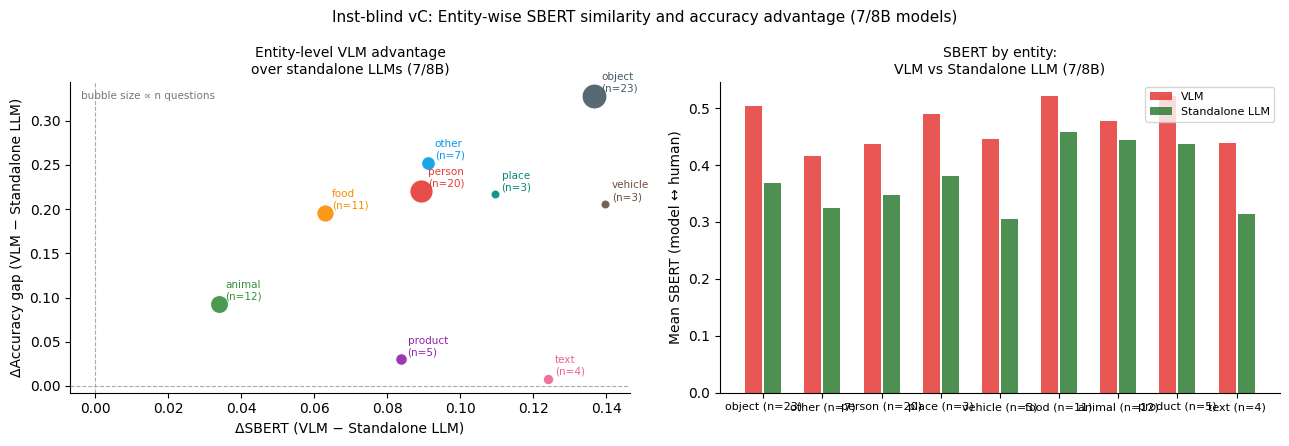


Summary (sorted by Δgap, 7B only):
Entity       n_q    ΔSBERT      ΔGap
--------------------------------------
object        23    +0.137    +0.328
other          7    +0.091    +0.252
person        20    +0.089    +0.220
place          3    +0.109    +0.217
vehicle        3    +0.140    +0.206
food          11    +0.063    +0.195
animal        12    +0.034    +0.093
product        5    +0.084    +0.030
text           4    +0.124    +0.008


In [15]:
# ── Entity-wise breakdown (self-contained, 7B only) ──────────────────────────
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms

_7b_set = set(MODELS_7B)

_ent_pair = pd.read_parquet(EXPORTS / "pair_cache_raw.parquet")
_ent_pc = _ent_pair[(_ent_pair["variant"] == "C") & (_ent_pair["pair_type"] == "HM")].copy()
# Filter to 7B models only
_ent_pc = _ent_pc[_ent_pc["subject_2"].isin(_7b_set)].copy()
_ent_hm = (_ent_pc.groupby(["question_id", "subject_2"])
           [["sbert_score", "chrf_score", "exact_score"]].mean()
           .reset_index().rename(columns={"subject_2": "model"}))
_ent_base = pd.read_csv(EXPORTS / "responses_model_inst_blind.csv")
_ent_base = _ent_base[(_ent_base["variant"] == "C") & (_ent_base["model"].isin(_7b_set))].copy()
_ent_base["acc_gap"] = _ent_base["accuracy"] - _ent_base["human_avg_acc"]
_ent_joined = _ent_base.merge(_ent_hm, on=["question_id", "model"], how="inner")

print(f"7B models in data: {_ent_joined['model'].nunique()}")
print(f"Questions: {_ent_joined['question_id'].nunique()}")

ent_order_all = (
    _ent_joined.groupby("question_id")["ent"].first().value_counts().index.tolist()
)

delta_rows = []
for ent in ent_order_all:
    sub_vlm = _ent_joined[(_ent_joined["ent"] == ent) & (_ent_joined["model_group"] == "VLM")]
    sub_llm = _ent_joined[(_ent_joined["ent"] == ent) & (_ent_joined["model_group"] == "standalone LLM")]
    n_q = _ent_joined[_ent_joined["ent"] == ent]["question_id"].nunique()
    if sub_vlm.empty or sub_llm.empty or n_q < 3:
        continue
    delta_rows.append({
        "ent":         ent,
        "n_q":         n_q,
        "delta_sbert": sub_vlm["sbert_score"].mean() - sub_llm["sbert_score"].mean(),
        "delta_gap":   sub_vlm["acc_gap"].mean()     - sub_llm["acc_gap"].mean(),
        "vlm_sbert":   sub_vlm["sbert_score"].mean(),
        "llm_sbert":   sub_llm["sbert_score"].mean(),
        "vlm_gap":     sub_vlm["acc_gap"].mean(),
        "llm_gap":     sub_llm["acc_gap"].mean(),
    })
delta_df = pd.DataFrame(delta_rows).sort_values("delta_gap", ascending=False)

ent_colors = {
    "object": "#455A64", "person": "#E53935", "animal": "#388E3C",
    "food":   "#FB8C00", "product": "#8E24AA", "other":  "#039BE5",
    "vehicle":"#6D4C41", "place":  "#00897B",  "text":   "#F06292",
}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# ── Left: Δ scatter per entity ────────────────────────────────────────────────
ax = axes[0]
for _, row in delta_df.iterrows():
    color = ent_colors.get(row["ent"], "#888")
    ax.scatter(row["delta_sbert"], row["delta_gap"],
               s=row["n_q"] * 14, color=color, zorder=3,
               edgecolors="white", linewidths=0.8, alpha=0.9)
    ax.annotate(f'{row["ent"]}\n(n={row["n_q"]:g})',
                (row["delta_sbert"], row["delta_gap"]),
                xytext=(5, 3), textcoords="offset points",
                fontsize=7.5, color=color)
ax.axhline(0, color="#aaa", lw=0.8, ls="--")
ax.axvline(0, color="#aaa", lw=0.8, ls="--")
ax.set_xlabel("ΔSBERT (VLM − Standalone LLM)", fontsize=10)
ax.set_ylabel("ΔAccuracy gap (VLM − Standalone LLM)", fontsize=10)
ax.set_title("Entity-level VLM advantage\nover standalone LLMs (7/8B)", fontsize=10)
ax.spines[["top", "right"]].set_visible(False)
ax.text(0.02, 0.97, "bubble size ∝ n questions",
        transform=ax.transAxes, fontsize=7.5, color="#777", va="top")

# ── Right: SBERT bars per entity ──────────────────────────────────────────────
ax = axes[1]
x = np.arange(len(delta_df)); w = 0.32
vlm_color = GROUP_COLORS.get("VLM", "#E53935")
llm_color  = GROUP_COLORS.get("standalone LLM", "#1976D2")
for i, (_, row) in enumerate(delta_df.iterrows()):
    ax.bar(i - w/2, row["vlm_sbert"], w * 0.9, color=vlm_color, alpha=0.85,
           label="VLM" if i == 0 else "_")
    ax.bar(i + w/2, row["llm_sbert"], w * 0.9, color=llm_color, alpha=0.85,
           label="Standalone LLM" if i == 0 else "_")
ax.set_xticks(x)
ax.set_xticklabels(
    [f'{r["ent"]} (n={r["n_q"]:g})' for _, r in delta_df.iterrows()],
    fontsize=8)
ax.set_ylabel("Mean SBERT (model ↔ human)", fontsize=10)
ax.set_title("SBERT by entity:\nVLM vs Standalone LLM (7/8B)", fontsize=10)
ax.legend(fontsize=8, frameon=True)
ax.spines[["top", "right"]].set_visible(False)

plt.suptitle("Inst-blind vC: Entity-wise SBERT similarity and accuracy advantage (7/8B models)", fontsize=11)
plt.tight_layout()
plt.show()

print("\nSummary (sorted by Δgap, 7B only):")
print(f"{'Entity':<10}  {'n_q':>4}  {'ΔSBERT':>8}  {'ΔGap':>8}")
print("-" * 38)
for _, row in delta_df.iterrows():
    print(f"{row['ent']:<10}  {row['n_q']:4g}  {row['delta_sbert']:+8.3f}  {row['delta_gap']:+8.3f}")

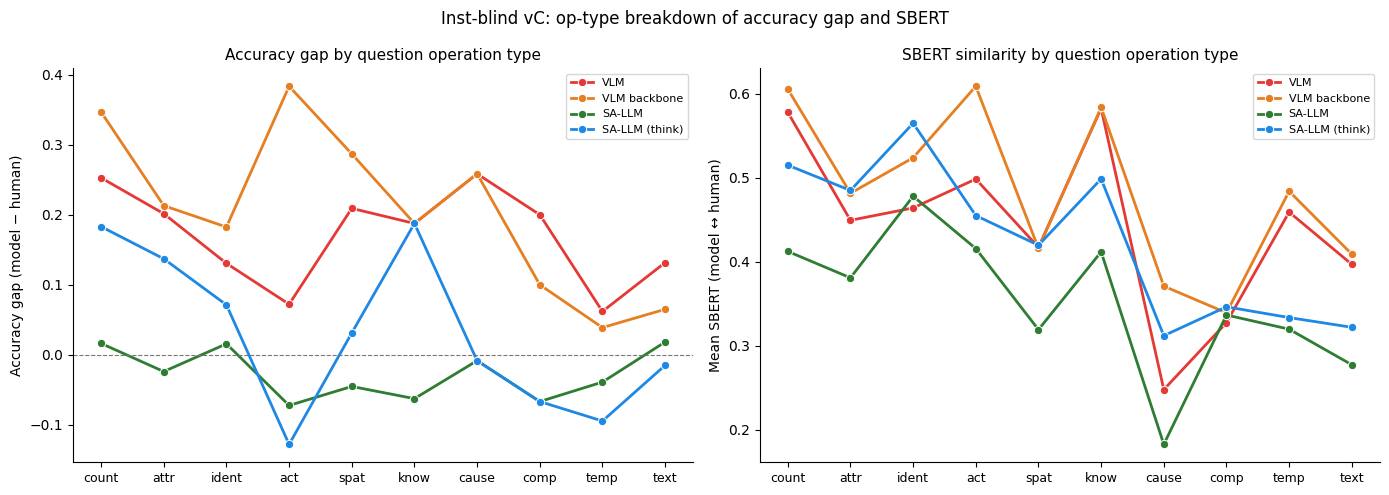

In [16]:
OP_ORDER = ['count', 'attr', 'ident', 'act', 'spat', 'know', 'cause', 'comp', 'temp', 'text']
OP_ORDER = [o for o in OP_ORDER if o in op_gap['op'].unique()]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: accuracy gap by op, one line per model group
ax = axes[0]
for grp in GROUP_ORDER:
    sub = op_gap[op_gap['model_group'] == grp].set_index('op').reindex(OP_ORDER)
    color = GROUP_COLORS.get(grp, '#888')
    ax.plot(range(len(OP_ORDER)), sub['mean_acc_gap'].values,
            color=color, lw=2, marker='o', markersize=6,
            markeredgecolor='white', markeredgewidth=0.7,
            label=grp.replace('standalone LLM', 'SA-LLM').replace('backbone decoder', 'backbone'))
ax.axhline(0, color='#777', lw=0.8, ls='--')
ax.set_xticks(range(len(OP_ORDER)))
ax.set_xticklabels(OP_ORDER, fontsize=9)
ax.set_ylabel('Accuracy gap (model − human)', fontsize=10)
ax.set_title('Accuracy gap by question operation type', fontsize=11)
ax.legend(fontsize=8, frameon=True)
ax.spines[['top', 'right']].set_visible(False)

# Right: SBERT by op, one line per model group
ax = axes[1]
for grp in GROUP_ORDER:
    sub = op_gap[op_gap['model_group'] == grp].set_index('op').reindex(OP_ORDER)
    color = GROUP_COLORS.get(grp, '#888')
    ax.plot(range(len(OP_ORDER)), sub['mean_sbert'].values,
            color=color, lw=2, marker='o', markersize=6,
            markeredgecolor='white', markeredgewidth=0.7,
            label=grp.replace('standalone LLM', 'SA-LLM').replace('backbone decoder', 'backbone'))
ax.set_xticks(range(len(OP_ORDER)))
ax.set_xticklabels(OP_ORDER, fontsize=9)
ax.set_ylabel('Mean SBERT (model ↔ human)', fontsize=10)
ax.set_title('SBERT similarity by question operation type', fontsize=11)
ax.legend(fontsize=8, frameon=True)
ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('Inst-blind vC: op-type breakdown of accuracy gap and SBERT', fontsize=12)
plt.tight_layout()
plt.show()

In [17]:
# The key question: for count and attr questions, what is the model guessing?
# Show the modal model answer vs GT for high-gap op types

for op_type in ['count', 'attr', 'spat']:
    sub = joined[(joined['op'] == op_type) & (joined['model_group'] == 'VLM')]
    if sub.empty:
        continue
    # Aggregate to question level
    q_sub = sub.groupby(['question_id', 'question_en', 'gt', 'human_avg_acc']).agg(
        mean_model_acc=('accuracy', 'mean'),
        mean_acc_gap=('acc_gap', 'mean'),
    ).reset_index().sort_values('mean_acc_gap', ascending=False)
    print(f'\n── op={op_type} (n={len(q_sub)} questions) ──')
    print(f'  Mean acc gap: {q_sub["mean_acc_gap"].mean():.3f}')
    print(q_sub[['question_en', 'gt', 'human_avg_acc', 'mean_model_acc', 'mean_acc_gap']].head(8).to_string(index=False, max_colwidth=55))


── op=count (n=22 questions) ──
  Mean acc gap: 0.253
                                  question_en                                                 gt  human_avg_acc  mean_model_acc  mean_acc_gap
     How many apple trees are in the picture?              0 | 0 | 2 | 0 | 0 | 0 | 0 | 0 | 0 | 0       0.033333             1.0      0.966667
             How many hearts are on the desk?              0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0       0.050000             1.0      0.950000
  How many bottles of water are on the table?              0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0       0.000000             0.8      0.800000
          How many shoes are under the table?              0 | 0 | 0 | 0 | 0 | 1 | 0 | 0 | 0 | 0       0.016667             0.8      0.783333
How many black lines are on the girl's shirt? 0 | 15 | 13 | 0 | several | many | 15 | 16 | 7 | 0       0.108333             0.8      0.691667
           How many people are wearing peach?    0 | many | many | 10 | 0 | 10 | 16 | 4 | 15 

## 9. Blind vs inst-blind comparison

Does the SBERT–accuracy dissociation strengthen or weaken when the instruction is added?

In [18]:
# HM pairs for blind condition — need to check if pair_cache has blind condition
# pair_cache is built from inst_blind by default; check pair_type coverage
print('Pair cache pair types:', pair_cache['pair_type'].value_counts().to_dict())
# The accuracy gap comparison blind vs inst_blind
grp_both = acc_df.groupby(['model_group', 'condition']).agg(
    mean_model_acc=('accuracy', 'mean'),
    mean_human_acc=('human_avg_acc', 'mean'),
    mean_acc_gap=('acc_gap', 'mean'),
).reset_index().pivot(index='model_group', columns='condition', values=['mean_model_acc', 'mean_acc_gap'])
grp_both.columns = ['_'.join(c) for c in grp_both.columns]
grp_both['gap_delta'] = grp_both['mean_acc_gap_inst_blind'] - grp_both['mean_acc_gap_blind']
print('\nAccuracy gap: blind vs inst_blind (gap_delta = inst_blind − blind):')
print(grp_both[['mean_model_acc_blind','mean_model_acc_inst_blind',
                'mean_acc_gap_blind','mean_acc_gap_inst_blind','gap_delta']].to_string())

Pair cache pair types: {'HM': 389360, 'HH': 205920, 'MM': 174753}

Accuracy gap: blind vs inst_blind (gap_delta = inst_blind − blind):
                        mean_model_acc_blind  mean_model_acc_inst_blind  mean_acc_gap_blind  mean_acc_gap_inst_blind  gap_delta
model_group                                                                                                                    
VLM                                 0.489676                   0.473995            0.227434                 0.211791  -0.015643
VLM backbone decoder                0.431268                   0.467847            0.169027                 0.205605   0.036578
standalone LLM                      0.160428                   0.190987           -0.102317                -0.070440   0.031877
standalone LLM (think)              0.309524                   0.271386            0.044940                 0.009145  -0.035796


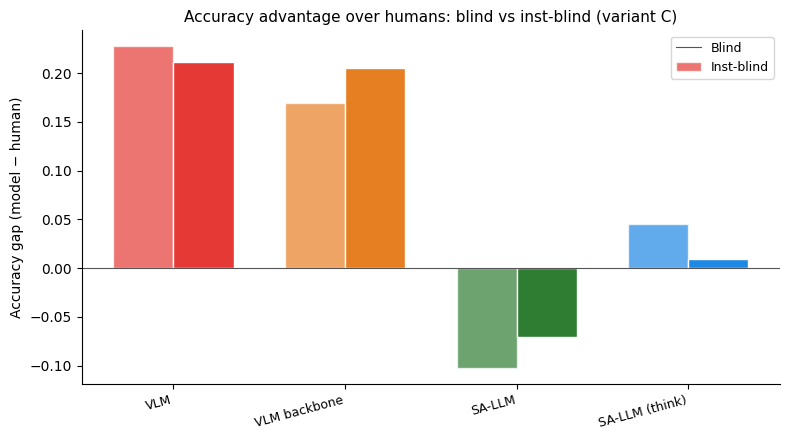

In [19]:
# Visualise: grouped bar chart of accuracy gap by condition
fig, ax = plt.subplots(figsize=(8, 4.5))

grp_bar = acc_df.groupby(['model_group', 'condition'])['acc_gap'].mean().reset_index()
conditions = ['blind', 'inst_blind']
x = np.arange(len(GROUP_ORDER))
w = 0.35

for i, cond in enumerate(conditions):
    vals = [grp_bar.loc[(grp_bar['model_group']==g) & (grp_bar['condition']==cond), 'acc_gap'].values
            for g in GROUP_ORDER]
    vals = [v[0] if len(v) else np.nan for v in vals]
    bars = ax.bar(x + (i - 0.5) * w, vals, w,
                  color=[GROUP_COLORS.get(g, '#888') for g in GROUP_ORDER],
                  alpha=0.7 if cond == 'blind' else 1.0,
                  label=cond,
                  edgecolor='white')

ax.axhline(0, color='#555', lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels([g.replace('standalone LLM', 'SA-LLM').replace('backbone decoder', 'backbone') 
                    for g in GROUP_ORDER], fontsize=9, rotation=15, ha='right')
ax.set_ylabel('Accuracy gap (model − human)', fontsize=10)
ax.set_title('Accuracy advantage over humans: blind vs inst-blind (variant C)', fontsize=11)
ax.legend(['Blind', 'Inst-blind'], fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

## 10. Summary findings

In [20]:
print('═' * 70)
print('SUMMARY: SBERT–Accuracy Dissociation')
print('═' * 70)

for grp in GROUP_ORDER:
    sub = model_summary[model_summary['model_group'] == grp]
    if sub.empty:
        continue
    print(f'\n{grp}:')
    print(f'  SBERT (model↔human):  {sub["mean_sbert"].mean():.3f}')
    print(f'  Model accuracy:       {sub["mean_model_acc"].mean():.3f}')
    print(f'  Human accuracy:       {sub["mean_human_acc"].mean():.3f}')
    print(f'  Accuracy gap:         {sub["mean_acc_gap"].mean():+.3f}')

print('\n── Interpretation ──')
print('High SBERT + high accuracy gap = models use same semantic register')
print('as humans (short, concrete answers) but produce the VQA-calibrated')
print('answer more reliably. This is consistent with linguistic prior')
print('exploitation, not perceptual reasoning.')

══════════════════════════════════════════════════════════════════════
SUMMARY: SBERT–Accuracy Dissociation
══════════════════════════════════════════════════════════════════════

VLM:
  SBERT (model↔human):  0.476
  Model accuracy:       0.360
  Human accuracy:       0.164
  Accuracy gap:         +0.195

VLM backbone decoder:
  SBERT (model↔human):  0.506
  Model accuracy:       0.407
  Human accuracy:       0.165
  Accuracy gap:         +0.242

standalone LLM:
  SBERT (model↔human):  0.381
  Model accuracy:       0.151
  Human accuracy:       0.165
  Accuracy gap:         -0.014

standalone LLM (think):
  SBERT (model↔human):  0.472
  Model accuracy:       0.261
  Human accuracy:       0.165
  Accuracy gap:         +0.097

── Interpretation ──
High SBERT + high accuracy gap = models use same semantic register
as humans (short, concrete answers) but produce the VQA-calibrated
answer more reliably. This is consistent with linguistic prior
exploitation, not perceptual reasoning.


## 11. Multi-metric agreement vs accuracy

**Question:** Is the backbone decoder's high human-agreement driven by answer *style* (short, VQA-format responses) or genuine *content* agreement? If SBERT is inflated by format similarity, content-heavy metrics (exact match, Jaccard, chrF) should tell a different story.

**Test:** (1) Compare all HM metrics by group against the HH baseline. (2) Correlate each metric with blind accuracy *within* groups — if agreement and accuracy decouple within VQA-trained models, the extra accuracy comes from prior exploitation, not human-like reasoning.

In [21]:
# ── 11a. HM agreement by group, all metrics, with HH baseline ─────────────────
from scipy.stats import pearsonr

_7b_set = set(MODELS_7B)

METRICS = ['exact_score', 'jaccard_score', 'rouge1_score', 'chrf_score',
           'bertscore_f1', 'sbert_score', 'simcse_score']
METRIC_LABELS = ['Exact', 'Jaccard', 'ROUGE-1', 'chrF', 'BERTScore', 'SBERT', 'SimCSE']

hm_all = pc_vC[pc_vC['pair_type'] == 'HM'].copy()
hm_7b = hm_all[hm_all['subject_2'].isin(_7b_set)]
hh_all = pc_vC[pc_vC['pair_type'] == 'HH']

# Group means (7B)
grp_means = hm_7b.groupby('subject_group_2')[METRICS].mean()
grp_means = grp_means.reindex(['VLM', 'VLM backbone decoder', 'standalone LLM', 'standalone LLM (think)'])
hh_means = hh_all[METRICS].mean()

print('HM agreement by group (variant C, 7B):')
print(grp_means.round(3).to_string())
print(f'\nHH baseline: {hh_means.round(3).to_dict()}')

HM agreement by group (variant C, 7B):
                        exact_score  jaccard_score  rouge1_score  chrf_score  bertscore_f1  sbert_score  simcse_score
subject_group_2                                                                                                      
VLM                           0.092          0.105         0.110       0.155         0.934        0.476         0.555
VLM backbone decoder          0.110          0.127         0.134       0.181         0.934        0.506         0.581
standalone LLM                0.053          0.069         0.077       0.102         0.873        0.381         0.500
standalone LLM (think)        0.091          0.112         0.120       0.165         0.915        0.472         0.558

HH baseline: {'exact_score': 0.127, 'jaccard_score': 0.144, 'rouge1_score': 0.151, 'chrf_score': 0.188, 'bertscore_f1': 0.932, 'sbert_score': 0.509, 'simcse_score': 0.58}


Saved: /home/david/Desktop/yuna/HPA/figures/supplementary/sbert_gap_7b/metric_comparison_groups_7b


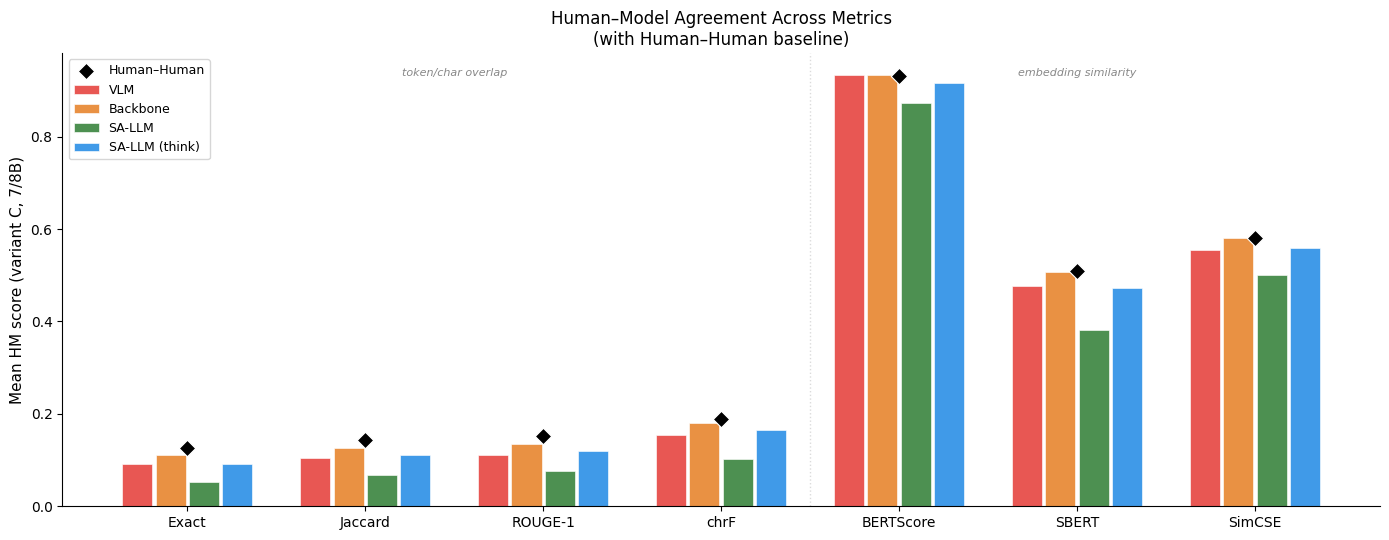

In [22]:
# ── 11b. Grouped bar: all metrics by group with HH baseline ──────────────────

fig, ax = plt.subplots(figsize=(14, 5.5))

grp_order = ['VLM', 'VLM backbone decoder', 'standalone LLM', 'standalone LLM (think)']
grp_short = {
    'VLM': 'VLM', 'VLM backbone decoder': 'Backbone',
    'standalone LLM': 'SA-LLM', 'standalone LLM (think)': 'SA-LLM (think)',
}

n_metrics = len(METRICS)
n_groups = len(grp_order)
x = np.arange(n_metrics)
total_w = 0.75
w = total_w / n_groups

for gi, grp in enumerate(grp_order):
    vals = grp_means.loc[grp, METRICS].values
    offset = (gi - (n_groups - 1) / 2) * w
    color = GROUP_COLORS.get(grp, '#888')
    bars = ax.bar(x + offset, vals, w * 0.9, color=color, alpha=0.85,
                  label=grp_short[grp], edgecolor='white', linewidth=0.5)

# HH baseline as diamonds
ax.scatter(x, hh_means[METRICS].values, marker='D', s=70, color='black',
           zorder=5, label='Human–Human', edgecolors='white', linewidths=0.8)

ax.set_xticks(x)
ax.set_xticklabels(METRIC_LABELS, fontsize=10)
ax.set_ylabel('Mean HM score (variant C, 7/8B)', fontsize=11)
ax.set_title('Human–Model Agreement Across Metrics\n(with Human–Human baseline)', fontsize=12)
ax.legend(fontsize=9, frameon=True, loc='upper left')
ax.spines[['top', 'right']].set_visible(False)

# Separate y-axis zones since BERTScore/SBERT/SimCSE are on different scale
ax.axvline(3.5, color='#ccc', lw=1, ls=':', alpha=0.7)
ax.text(1.5, ax.get_ylim()[1] * 0.95, 'token/char overlap', ha='center',
        fontsize=8, color='#888', style='italic')
ax.text(5.0, ax.get_ylim()[1] * 0.95, 'embedding similarity', ha='center',
        fontsize=8, color='#888', style='italic')

plt.tight_layout()
save_fig(fig, OUT_DIR, 'metric_comparison_groups_7b')
plt.show()

In [23]:
# ── 11c. Within-group correlation: HM metric vs blind accuracy ────────────────
# This is the key test: within VQA-trained models, does higher human agreement
# predict higher accuracy? If not, the extra accuracy is from prior exploitation.

model_acc = inst_blind_vC.groupby(['model', 'model_group'])['accuracy'].mean().reset_index()
model_hm = hm_7b.groupby('subject_2')[METRICS].mean().reset_index().rename(columns={'subject_2': 'model'})
merged = model_acc[model_acc['model'].isin(_7b_set)].merge(model_hm, on='model')

GROUP_SETS = {
    'All models': None,
    'VLM + Backbone': ['VLM', 'VLM backbone decoder'],
    'Standalone LLM (all)': ['standalone LLM', 'standalone LLM (think)'],
}

corr_rows = []
for set_name, groups in GROUP_SETS.items():
    sub = merged if groups is None else merged[merged['model_group'].isin(groups)]
    for m, ml in zip(METRICS, METRIC_LABELS):
        valid = sub.dropna(subset=[m, 'accuracy'])
        if len(valid) > 3:
            r, p = pearsonr(valid[m], valid['accuracy'])
            corr_rows.append({'subset': set_name, 'metric': ml, 'r': r, 'p': p, 'n': len(valid)})

corr_df = pd.DataFrame(corr_rows)
corr_pivot = corr_df.pivot(index='metric', columns='subset', values='r')
corr_pivot = corr_pivot.reindex(METRIC_LABELS)[['All models', 'VLM + Backbone', 'Standalone LLM (all)']]

print('Pearson r: HM metric vs blind accuracy (per-model, 7B)')
print(corr_pivot.round(3).to_string())
print()

# significance markers
p_pivot = corr_df.pivot(index='metric', columns='subset', values='p').reindex(METRIC_LABELS)
for col in corr_pivot.columns:
    sigs = []
    for m in METRIC_LABELS:
        p = p_pivot.loc[m, col]
        r = corr_pivot.loc[m, col]
        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
        sigs.append(f'{r:.3f} {sig}')
    print(f'{col}: {", ".join(sigs)}')

Pearson r: HM metric vs blind accuracy (per-model, 7B)
subset     All models  VLM + Backbone  Standalone LLM (all)
metric                                                     
Exact           0.775          -0.124                 0.947
Jaccard         0.698          -0.335                 0.941
ROUGE-1         0.653          -0.409                 0.935
chrF            0.717          -0.389                 0.936
BERTScore       0.922           0.735                 0.978
SBERT           0.782          -0.385                 0.958
SimCSE          0.732          -0.371                 0.966

All models: 0.775 ***, 0.698 **, 0.653 **, 0.717 **, 0.922 ***, 0.782 ***, 0.732 **
VLM + Backbone: -0.124 ns, -0.335 ns, -0.409 ns, -0.389 ns, 0.735 *, -0.385 ns, -0.371 ns
Standalone LLM (all): 0.947 *, 0.941 *, 0.935 *, 0.936 *, 0.978 **, 0.958 *, 0.966 **


Saved: /home/david/Desktop/yuna/HPA/figures/supplementary/sbert_gap_7b/metric_vs_accuracy_scatter_7b


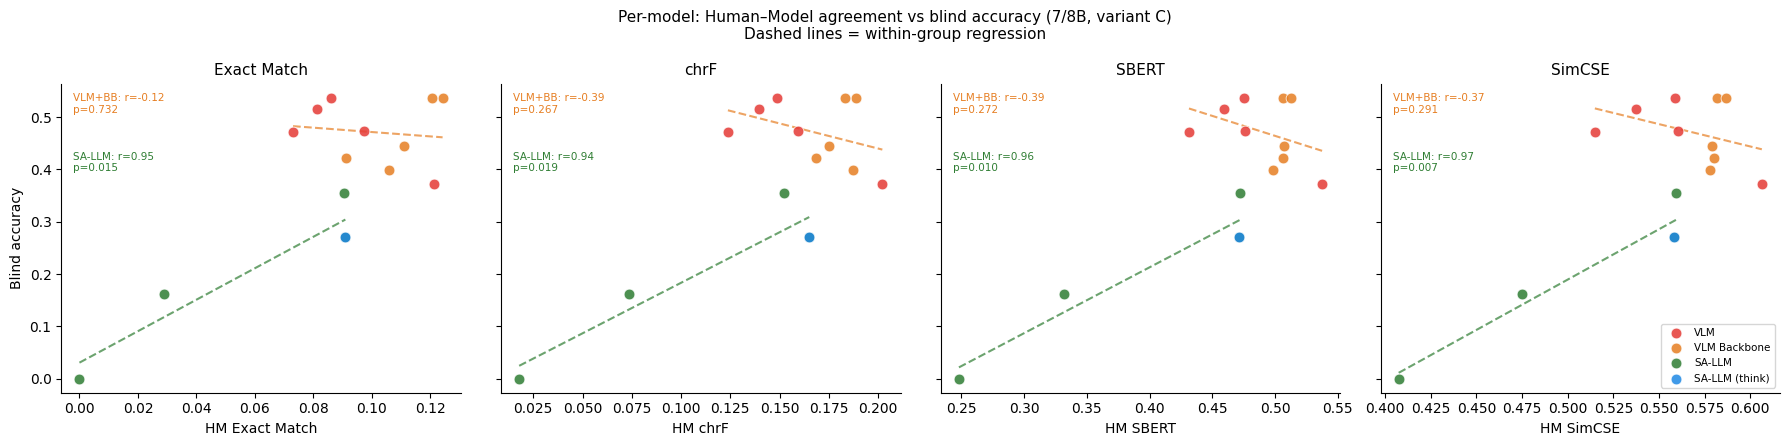

In [24]:
# ── 11d. Scatter: per-model accuracy vs HM metric (4 key metrics) ────────────
PLOT_METRICS = [
    ('exact_score', 'Exact Match'),
    ('chrf_score', 'chrF'),
    ('sbert_score', 'SBERT'),
    ('simcse_score', 'SimCSE'),
]

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5), sharey=True)

for ax, (mcol, mlabel) in zip(axes, PLOT_METRICS):
    for grp in GROUP_ORDER:
        sub = merged[merged['model_group'] == grp]
        if sub.empty:
            continue
        color = GROUP_COLORS.get(grp, '#888')
        ax.scatter(sub[mcol], sub['accuracy'], color=color, s=60,
                   alpha=0.85, edgecolors='white', linewidths=0.6, zorder=3,
                   label=grp.replace('standalone LLM', 'SA-LLM').replace('backbone decoder', 'Backbone'))

    # Within VLM+backbone regression
    vb = merged[merged['model_group'].isin(['VLM', 'VLM backbone decoder'])].dropna(subset=[mcol])
    if len(vb) > 3:
        r_vb, p_vb = pearsonr(vb[mcol], vb['accuracy'])
        m_, b_ = np.polyfit(vb[mcol], vb['accuracy'], 1)
        xr = np.linspace(vb[mcol].min(), vb[mcol].max(), 50)
        ax.plot(xr, m_ * xr + b_, color='#E67E22', lw=1.5, ls='--', alpha=0.7)
        ax.text(0.03, 0.97, f'VLM+BB: r={r_vb:.2f}\np={p_vb:.3f}',
                transform=ax.transAxes, fontsize=7.5, va='top', color='#E67E22')

    # Within SA-LLM regression
    sa = merged[merged['model_group'].isin(['standalone LLM', 'standalone LLM (think)'])].dropna(subset=[mcol])
    if len(sa) > 3:
        r_sa, p_sa = pearsonr(sa[mcol], sa['accuracy'])
        m_, b_ = np.polyfit(sa[mcol], sa['accuracy'], 1)
        xr = np.linspace(sa[mcol].min(), sa[mcol].max(), 50)
        ax.plot(xr, m_ * xr + b_, color='#2E7D32', lw=1.5, ls='--', alpha=0.7)
        ax.text(0.03, 0.78, f'SA-LLM: r={r_sa:.2f}\np={p_sa:.3f}',
                transform=ax.transAxes, fontsize=7.5, va='top', color='#2E7D32')

    ax.set_xlabel(f'HM {mlabel}', fontsize=10)
    ax.set_title(mlabel, fontsize=11)
    ax.spines[['top', 'right']].set_visible(False)

axes[0].set_ylabel('Blind accuracy', fontsize=10)
axes[-1].legend(fontsize=7.5, frameon=True, loc='lower right')

fig.suptitle('Per-model: Human–Model agreement vs blind accuracy (7/8B, variant C)\n'
             'Dashed lines = within-group regression',
             fontsize=11)
plt.tight_layout()
save_fig(fig, OUT_DIR, 'metric_vs_accuracy_scatter_7b')
plt.show()

Saved: /home/david/Desktop/yuna/HPA/figures/supplementary/sbert_gap_7b/hm_agreement_by_op_7b


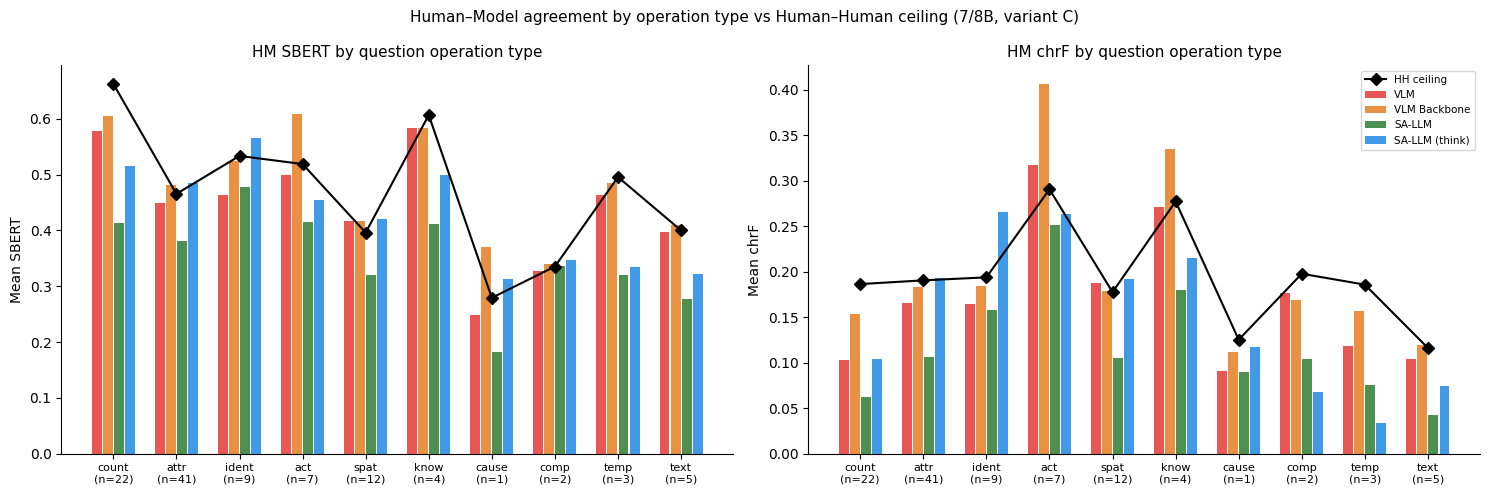

In [25]:
# ── 11f. HM agreement by op type per group, with HH ceiling ──────────────────
# Per-question HH baseline by op
q_meta = inst_blind_vC.groupby('question_id')[['op', 'ent']].first().reset_index()

hh_q = hh_all.groupby('question_id')[METRICS].mean().reset_index()
hh_q = hh_q.merge(q_meta, on='question_id', how='inner')
hh_by_op = hh_q.groupby('op')[METRICS].mean()

# Per-question HM by group and op
hm_q = hm_7b.groupby(['question_id', 'subject_group_2'])[METRICS].mean().reset_index()
hm_q = hm_q.merge(q_meta, on='question_id', how='inner')
hm_by_op_grp = hm_q.groupby(['op', 'subject_group_2'])[METRICS].mean()

# Plot: SBERT and chrF side-by-side, by op type, per group + HH ceiling
PLOT_M = [('sbert_score', 'SBERT'), ('chrf_score', 'chrF')]
op_order = ['count', 'attr', 'ident', 'act', 'spat', 'know', 'cause', 'comp', 'temp', 'text']
op_order = [o for o in op_order if o in hh_by_op.index]

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=False)

for ax, (mcol, mlabel) in zip(axes, PLOT_M):
    x = np.arange(len(op_order))
    n_grps = len(GROUP_ORDER)
    w = 0.7 / n_grps

    for gi, grp in enumerate(GROUP_ORDER):
        vals = []
        for op in op_order:
            try:
                vals.append(hm_by_op_grp.loc[(op, grp), mcol])
            except KeyError:
                vals.append(np.nan)
        offset = (gi - (n_grps - 1) / 2) * w
        color = GROUP_COLORS.get(grp, '#888')
        ax.bar(x + offset, vals, w * 0.9, color=color, alpha=0.85,
               label=grp.replace('standalone LLM', 'SA-LLM').replace('backbone decoder', 'Backbone'))

    # HH ceiling line
    hh_vals = [hh_by_op.loc[op, mcol] if op in hh_by_op.index else np.nan for op in op_order]
    ax.plot(x, hh_vals, 'kD-', markersize=6, lw=1.5, label='HH ceiling', zorder=5)

    # Question counts per op
    op_counts = q_meta['op'].value_counts()
    tick_labels = [f'{op}\n(n={op_counts.get(op, 0)})' for op in op_order]
    ax.set_xticks(x)
    ax.set_xticklabels(tick_labels, fontsize=8)
    ax.set_ylabel(f'Mean {mlabel}', fontsize=10)
    ax.set_title(f'HM {mlabel} by question operation type', fontsize=11)
    ax.spines[['top', 'right']].set_visible(False)
    if ax == axes[-1]:
        ax.legend(fontsize=7.5, frameon=True, loc='upper right')

fig.suptitle('Human–Model agreement by operation type vs Human–Human ceiling (7/8B, variant C)',
             fontsize=11)
plt.tight_layout()
save_fig(fig, OUT_DIR, 'hm_agreement_by_op_7b')
plt.show()

Saved: /home/david/Desktop/yuna/HPA/figures/supplementary/sbert_gap_7b/hm_agreement_by_ent_7b


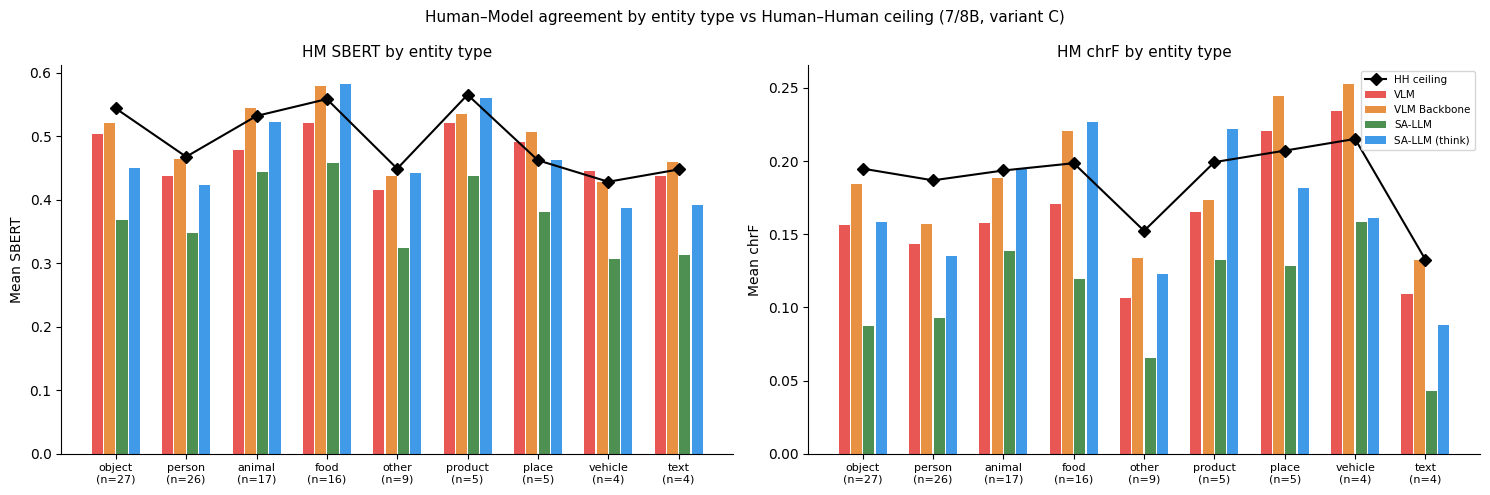


Distance from HH ceiling (HH − HM) by entity type, SBERT:
Entity        n             VLM  VLM backbone  standalone L  standalone L
object       27          +0.039        +0.023        +0.176        +0.094
person       26          +0.031        +0.003        +0.121        +0.044
animal       17          +0.054        -0.012        +0.088        +0.009
food         16          +0.038        -0.020        +0.101        -0.024
other         9          +0.033        +0.012        +0.124        +0.006
product       5          +0.045        +0.031        +0.128        +0.006
place         5          -0.028        -0.044        +0.081        -0.000
vehicle       4          -0.017        -0.000        +0.122        +0.042
text          4          +0.010        -0.012        +0.134        +0.056


In [26]:
# ── 11g. HM agreement by entity type per group, with HH ceiling ──────────────
hh_by_ent = hh_q.groupby('ent')[METRICS].mean()
hm_by_ent_grp = hm_q.groupby(['ent', 'subject_group_2'])[METRICS].mean()

ent_order = q_meta['ent'].value_counts().index.tolist()
ent_counts = q_meta['ent'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=False)

for ax, (mcol, mlabel) in zip(axes, PLOT_M):
    x = np.arange(len(ent_order))
    n_grps = len(GROUP_ORDER)
    w = 0.7 / n_grps

    for gi, grp in enumerate(GROUP_ORDER):
        vals = []
        for ent in ent_order:
            try:
                vals.append(hm_by_ent_grp.loc[(ent, grp), mcol])
            except KeyError:
                vals.append(np.nan)
        offset = (gi - (n_grps - 1) / 2) * w
        color = GROUP_COLORS.get(grp, '#888')
        ax.bar(x + offset, vals, w * 0.9, color=color, alpha=0.85,
               label=grp.replace('standalone LLM', 'SA-LLM').replace('backbone decoder', 'Backbone'))

    # HH ceiling
    hh_vals = [hh_by_ent.loc[ent, mcol] if ent in hh_by_ent.index else np.nan for ent in ent_order]
    ax.plot(x, hh_vals, 'kD-', markersize=6, lw=1.5, label='HH ceiling', zorder=5)

    tick_labels = [f'{ent}\n(n={ent_counts.get(ent, 0)})' for ent in ent_order]
    ax.set_xticks(x)
    ax.set_xticklabels(tick_labels, fontsize=8)
    ax.set_ylabel(f'Mean {mlabel}', fontsize=10)
    ax.set_title(f'HM {mlabel} by entity type', fontsize=11)
    ax.spines[['top', 'right']].set_visible(False)
    if ax == axes[-1]:
        ax.legend(fontsize=7.5, frameon=True, loc='upper right')

fig.suptitle('Human–Model agreement by entity type vs Human–Human ceiling (7/8B, variant C)',
             fontsize=11)
plt.tight_layout()
save_fig(fig, OUT_DIR, 'hm_agreement_by_ent_7b')
plt.show()

# ── Distance from HH ceiling ────────────────────────────────────────────────
print('\nDistance from HH ceiling (HH − HM) by entity type, SBERT:')
print(f'{"Entity":<10} {"n":>4}  ', end='')
for grp in GROUP_ORDER:
    print(f'{grp[:12]:>14}', end='')
print()
for ent in ent_order:
    hh_val = hh_by_ent.loc[ent, 'sbert_score'] if ent in hh_by_ent.index else np.nan
    print(f'{ent:<10} {ent_counts.get(ent,0):4}  ', end='')
    for grp in GROUP_ORDER:
        try:
            hm_val = hm_by_ent_grp.loc[(ent, grp), 'sbert_score']
            print(f'{hh_val - hm_val:+14.3f}', end='')
        except KeyError:
            print(f'{"N/A":>14}', end='')
    print()

=== Top 15 most human-aligned questions (HM SBERT, all 7B models) ===
                                    question_en    op     ent  hm_sbert_score  hh_sbert_score  sbert_gap_to_hh  hm_chrf_score  human_avg_acc
                 Do the horses love each other?   act  animal        0.801049        0.770355        -0.030694       0.628730       0.900000
                 What color are the appliances?  attr  object        0.771104        0.761055        -0.010049       0.375463       0.475000
     How many ski poles is this person holding? count  object        0.753989        0.749502        -0.004487       0.393187       0.550000
          What color of wine is in the glasses?  attr    food        0.746450        0.720651        -0.025798       0.414167       0.400000
            What condiments are on the hot dog? ident    food        0.701234        0.709283         0.008049       0.309016       0.041667
         What is the color of the dog's collar?  attr  object        0.698783       

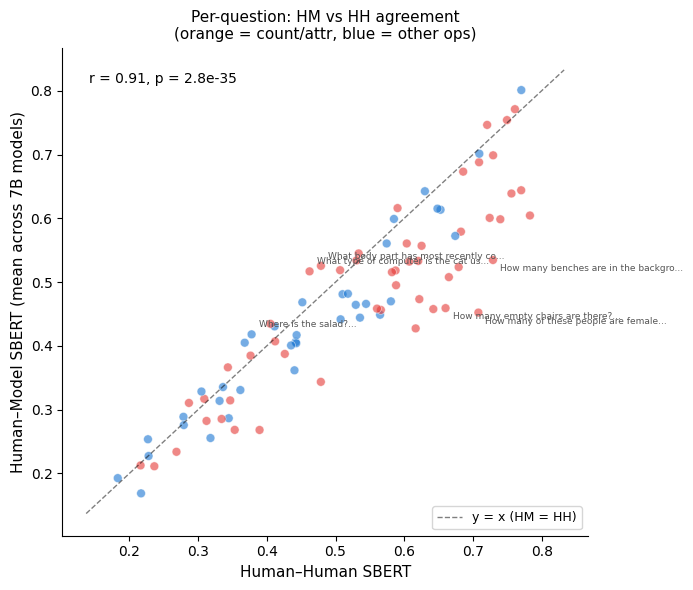

In [27]:
# ── 11h. Most/least aligned questions (ranked by HM SBERT, not accuracy) ─────
# Average HM SBERT across all 7B models per question, compare to HH SBERT

hm_q_all = hm_7b.groupby('question_id')[METRICS].mean().reset_index()
hm_q_all.columns = ['question_id'] + [f'hm_{m}' for m in METRICS]

hh_q_agg = hh_all.groupby('question_id')[METRICS].mean().reset_index()
hh_q_agg.columns = ['question_id'] + [f'hh_{m}' for m in METRICS]

q_align = hm_q_all.merge(hh_q_agg, on='question_id', how='inner')
q_align = q_align.merge(q_meta, on='question_id', how='inner')
# Add question text and GT from inst_blind
q_text = inst_blind_vC.groupby('question_id')[['question_en', 'gt', 'human_avg_acc']].first().reset_index()
q_align = q_align.merge(q_text, on='question_id', how='inner')

# Gap to HH ceiling
q_align['sbert_gap_to_hh'] = q_align['hh_sbert_score'] - q_align['hm_sbert_score']
q_align['chrf_gap_to_hh']  = q_align['hh_chrf_score']  - q_align['hm_chrf_score']

# Sort by HM SBERT (highest = most aligned with humans)
show_cols = ['question_en', 'op', 'ent', 'hm_sbert_score', 'hh_sbert_score',
             'sbert_gap_to_hh', 'hm_chrf_score', 'human_avg_acc']

print(f'=== Top 15 most human-aligned questions (HM SBERT, all 7B models) ===')
top = q_align.sort_values('hm_sbert_score', ascending=False).head(15)
print(top[show_cols].to_string(index=False, max_colwidth=55))

print(f'\n=== Bottom 15 least human-aligned questions ===')
bot = q_align.sort_values('hm_sbert_score', ascending=True).head(15)
print(bot[show_cols].to_string(index=False, max_colwidth=55))

# Summary stats
print(f'\n── Summary ──')
print(f'Mean HM SBERT: {q_align["hm_sbert_score"].mean():.3f}  (HH: {q_align["hh_sbert_score"].mean():.3f})')
print(f'Mean gap to HH: {q_align["sbert_gap_to_hh"].mean():.3f}')
print(f'Questions at or above HH ceiling: {(q_align["sbert_gap_to_hh"] <= 0).sum()} / {len(q_align)}')

# ── Scatter: HM SBERT vs HH SBERT per question ──────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))
colors = [GROUP_COLORS.get('VLM', '#E53935') if op in ('count', 'attr') else '#1976D2'
          for op in q_align['op']]
ax.scatter(q_align['hh_sbert_score'], q_align['hm_sbert_score'],
           c=colors, s=40, alpha=0.6, edgecolors='white', linewidths=0.5)
# y=x line
lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]), max(ax.get_xlim()[1], ax.get_ylim()[1])]
ax.plot(lims, lims, 'k--', lw=1, alpha=0.5, label='y = x (HM = HH)')

r, p = stats.pearsonr(q_align['hh_sbert_score'], q_align['hm_sbert_score'])
ax.text(0.05, 0.95, f'r = {r:.2f}, p = {p:.2g}', transform=ax.transAxes,
        fontsize=10, va='top')

# Annotate outliers
for _, row in q_align.nlargest(3, 'sbert_gap_to_hh').iterrows():
    ax.annotate(row['question_en'][:35] + '...', (row['hh_sbert_score'], row['hm_sbert_score']),
                fontsize=6.5, color='#555', xytext=(5, -8), textcoords='offset points')
for _, row in q_align.nsmallest(3, 'sbert_gap_to_hh').iterrows():
    ax.annotate(row['question_en'][:35] + '...', (row['hh_sbert_score'], row['hm_sbert_score']),
                fontsize=6.5, color='#555', xytext=(5, 5), textcoords='offset points')

ax.set_xlabel('Human–Human SBERT', fontsize=11)
ax.set_ylabel('Human–Model SBERT (mean across 7B models)', fontsize=11)
ax.set_title('Per-question: HM vs HH agreement\n(orange = count/attr, blue = other ops)', fontsize=11)
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
save_fig(fig, OUT_DIR, 'hm_vs_hh_sbert_per_question')
plt.show()

## 12. Confound check: abstention filtering

Two confounds threaten the HM agreement comparisons:
1. **Instruction → higher alignment** could be an artifact of fewer abstentions (model gives a substantive guess instead of "nothing" → SBERT jumps mechanically)
2. **SA-LLM low agreement** could be driven by verbose refusals ("I cannot answer without seeing...") that tank all metrics regardless of content

**Test:** Classify all responses, report abstention rates by group, then identify the **common question set** where *all* models gave substantive (non-abstained) answers. Comparing on this shared set ensures fair apples-to-apples: same questions, same human baselines, only the model answers differ.

In [28]:
# ── 12a. Classify all inst_blind responses ────────────────────────────────────
from utils.abstention import classify, is_abstained

inst_blind_vC['cls'] = inst_blind_vC.apply(
    lambda r: classify(str(r['response']), str(r['gt']).split(' | ') if pd.notna(r['gt']) else None),
    axis=1
)
inst_blind_vC['abstained'] = inst_blind_vC['cls'].apply(is_abstained)

# Also classify blind condition
blind_vC['cls'] = blind_vC.apply(
    lambda r: classify(str(r['response']), str(r['gt']).split(' | ') if pd.notna(r['gt']) else None),
    axis=1
)
blind_vC['abstained'] = blind_vC['cls'].apply(is_abstained)

# ── Abstention rates by group × condition ─────────────────────────────────────
print('=== Abstention rates by model group ===\n')
for cond_label, cond_df in [('blind', blind_vC), ('inst_blind', inst_blind_vC)]:
    print(f'── {cond_label} ──')
    grp_abs = cond_df.groupby('model_group').agg(
        n=('abstained', 'count'),
        n_abstained=('abstained', 'sum'),
        n_hard=('cls', lambda x: (x == 'hard_abstained').sum()),
        n_soft=('cls', lambda x: (x == 'soft_abstained').sum()),
    )
    grp_abs['rate_total'] = grp_abs['n_abstained'] / grp_abs['n']
    grp_abs['rate_hard']  = grp_abs['n_hard'] / grp_abs['n']
    grp_abs['rate_soft']  = grp_abs['n_soft'] / grp_abs['n']
    print(grp_abs[['n', 'n_abstained', 'rate_total', 'rate_hard', 'rate_soft']].round(3).to_string())
    print()

# Per-model detail for inst_blind
print('=== Per-model abstention (inst_blind) ===')
model_abs = inst_blind_vC.groupby(['model_group', 'model']).agg(
    n=('abstained', 'count'),
    n_abs=('abstained', 'sum'),
    n_hard=('cls', lambda x: (x == 'hard_abstained').sum()),
    n_soft=('cls', lambda x: (x == 'soft_abstained').sum()),
).reset_index()
model_abs['rate'] = model_abs['n_abs'] / model_abs['n']
print(model_abs.sort_values('rate', ascending=False)[['model_group', 'model', 'n', 'n_abs', 'rate', 'n_hard', 'n_soft']].to_string(index=False))

=== Abstention rates by model group ===

── blind ──
                          n  n_abstained  rate_total  rate_hard  rate_soft
model_group                                                               
VLM                     565           38       0.067      0.000      0.067
VLM backbone decoder    565           21       0.037      0.028      0.009
standalone LLM          561           67       0.119      0.100      0.020
standalone LLM (think)  112            7       0.062      0.000      0.062

── inst_blind ──
                          n  n_abstained  rate_total  rate_hard  rate_soft
model_group                                                               
VLM                     564           30       0.053      0.004      0.050
VLM backbone decoder    565            9       0.016      0.012      0.004
standalone LLM          466           40       0.086      0.082      0.004
standalone LLM (think)  113            0       0.000      0.000      0.000

=== Per-model abstention (in

In [29]:
# ── 12b. Common-question-set comparison ──────────────────────────────────────
# Fair comparison: find questions where ALL models gave substantive answers,
# then compare HM agreement on that shared set.

# Per (question, model): is it abstained?
abs_map = inst_blind_vC.set_index(['question_id', 'model'])['abstained']

all_models = inst_blind_vC['model'].unique()
all_questions = inst_blind_vC['question_id'].unique()

# For each question: how many models abstained?
q_abstain = inst_blind_vC.groupby('question_id')['abstained'].agg(['sum', 'count'])
q_abstain.columns = ['n_abstained', 'n_models']

# Tiered filtering: all-answer set vs relaxed thresholds
thresholds = [
    ('strict (0 abstain)',   0),
    ('≤1 model abstained',  1),
    ('≤2 models abstained', 2),
    ('≤25% abstained',      int(0.25 * len(all_models))),
]

print(f'Total questions: {len(all_questions)}, Total models: {len(all_models)}\n')
print('Question survival by filtering threshold:')
for label, max_abs in thresholds:
    n_q = (q_abstain['n_abstained'] <= max_abs).sum()
    print(f'  {label:<25s}: {n_q}/{len(all_questions)} questions ({100*n_q/len(all_questions):.0f}%)')

# Use strict=0 for the main comparison (all models answered)
common_q_strict = set(q_abstain[q_abstain['n_abstained'] == 0].index)
# Fallback: ≤1 abstain
common_q_relaxed = set(q_abstain[q_abstain['n_abstained'] <= 1].index)

print(f'\nUsing strict common set: {len(common_q_strict)} questions')
print(f'Relaxed fallback: {len(common_q_relaxed)} questions')

# ── Check composition of dropped questions ───────────────────────────────────
dropped_q = set(all_questions) - common_q_strict
if dropped_q:
    q_meta_full = inst_blind_vC.groupby('question_id')[['op', 'ent']].first()
    dropped_ops = q_meta_full.loc[list(dropped_q)]['op'].value_counts()
    dropped_ents = q_meta_full.loc[list(dropped_q)]['ent'].value_counts()
    print(f'\nDropped questions ({len(dropped_q)}) by op type:')
    print(dropped_ops.to_string())
    print(f'\nDropped questions by entity type:')
    print(dropped_ents.to_string())

Total questions: 113, Total models: 16

Question survival by filtering threshold:
  strict (0 abstain)       : 57/113 questions (50%)
  ≤1 model abstained       : 100/113 questions (88%)
  ≤2 models abstained      : 109/113 questions (96%)
  ≤25% abstained           : 112/113 questions (99%)

Using strict common set: 57 questions
Relaxed fallback: 100 questions

Dropped questions (56) by op type:
op
attr     21
count    13
spat      7
exist     5
act       3
temp      2
text      2
know      2
comp      1

Dropped questions by entity type:
ent
person     15
object     15
food        8
animal      7
other       4
product     3
vehicle     2
place       2


Using ≤1 abstain: 100 / 113 questions

Common questions in HM pair cache: 75

=== HM agreement: FULL set vs COMMON set (same Qs, all groups) ===

[VLM]  pairs: 17560 → 14960
  Exact     full=0.092  common=0.103  Δ=+0.011
  chrF      full=0.155  common=0.163  Δ=+0.008
  SBERT     full=0.476  common=0.495  Δ=+0.019
  SimCSE    full=0.555  common=0.572  Δ=+0.017

[VLM backbone decoder]  pairs: 17600 → 15000
  Exact     full=0.110  common=0.117  Δ=+0.006
  chrF      full=0.181  common=0.184  Δ=+0.003
  SBERT     full=0.506  common=0.519  Δ=+0.013
  SimCSE    full=0.581  common=0.589  Δ=+0.008

[standalone LLM]  pairs: 14080 → 12000
  Exact     full=0.053  common=0.059  Δ=+0.006
  chrF      full=0.102  common=0.108  Δ=+0.006
  SBERT     full=0.381  common=0.396  Δ=+0.014
  SimCSE    full=0.500  common=0.508  Δ=+0.008

[standalone LLM (think)]  pairs: 3520 → 3000
  Exact     full=0.091  common=0.103  Δ=+0.012
  chrF      full=0.165  common=0.173  Δ=+0.008
  SBERT     full=0.472  common=0.496

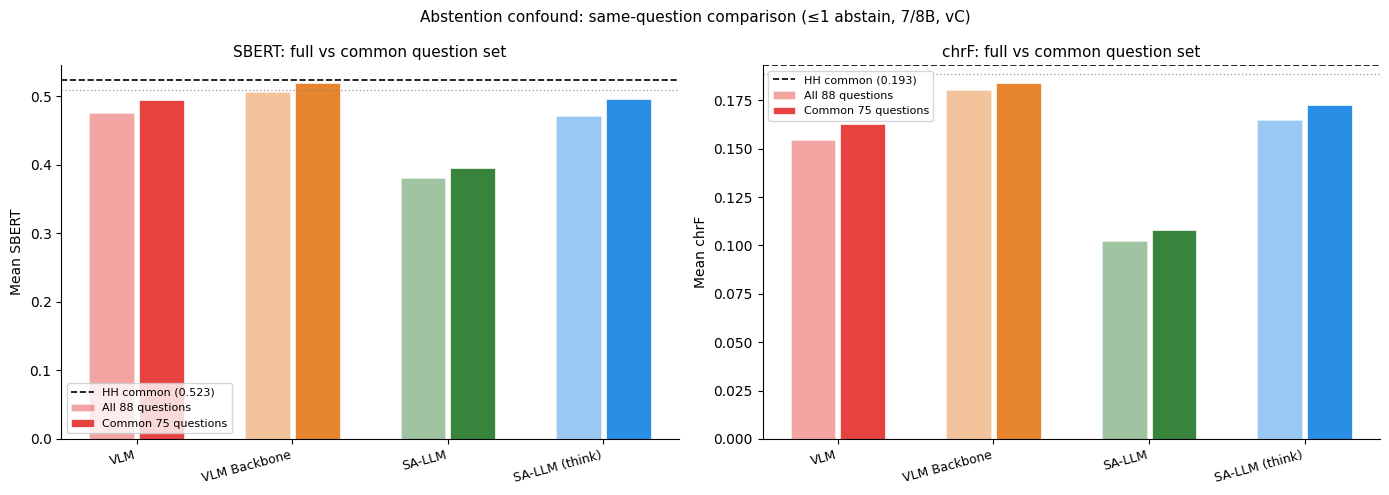


── VLM ↔ SA-LLM gap on common question set ──
  Exact     gap_full=0.039  gap_common=0.044  reduction=-13%
  chrF      gap_full=0.052  gap_common=0.055  reduction=-4%
  SBERT     gap_full=0.095  gap_common=0.099  reduction=-5%
  SimCSE    gap_full=0.056  gap_common=0.064  reduction=-16%


In [30]:
# ── 12c. HM agreement on common question set ────────────────────────────────
# Compare: full set vs common set (same questions for all groups)

# Pick the best threshold: strict if ≥60% questions survive, else relaxed
if len(common_q_strict) >= 0.6 * len(all_questions):
    common_q = common_q_strict
    filt_label = 'strict (0 abstain)'
else:
    common_q = common_q_relaxed
    filt_label = '≤1 abstain'
print(f'Using {filt_label}: {len(common_q)} / {len(all_questions)} questions\n')

# Filter HM pairs to common question set
hm_common = hm_7b[hm_7b['question_id'].isin(common_q)].copy()
hh_common = hh_all[hh_all['question_id'].isin(common_q)].copy()

# Also compute full-set restricted to the 88 HM questions (for apples-to-apples denominator)
hm_full_q = set(hm_7b['question_id'].unique())
common_q_in_hm = common_q & hm_full_q
hm_common = hm_7b[hm_7b['question_id'].isin(common_q_in_hm)].copy()
hh_common = hh_all[hh_all['question_id'].isin(common_q_in_hm)].copy()
print(f'Common questions in HM pair cache: {len(common_q_in_hm)}')

# Group means
grp_full   = hm_7b.groupby('subject_group_2')[METRICS].mean()
grp_common = hm_common.groupby('subject_group_2')[METRICS].mean()
hh_full    = hh_all[METRICS].mean()
hh_comm    = hh_common[METRICS].mean()

KEY_M = ['exact_score', 'chrf_score', 'sbert_score', 'simcse_score']
KEY_L = ['Exact', 'chrF', 'SBERT', 'SimCSE']

print('\n=== HM agreement: FULL set vs COMMON set (same Qs, all groups) ===\n')
for grp in GROUP_ORDER:
    if grp not in grp_common.index:
        print(f'[{grp}] — no data in common set')
        continue
    n_full = len(hm_7b[hm_7b['subject_group_2'] == grp])
    n_comm = len(hm_common[hm_common['subject_group_2'] == grp])
    print(f'[{grp}]  pairs: {n_full} → {n_comm}')
    for m, ml in zip(KEY_M, KEY_L):
        f = grp_full.loc[grp, m]
        c = grp_common.loc[grp, m]
        delta = c - f
        print(f'  {ml:<8}  full={f:.3f}  common={c:.3f}  Δ={delta:+.3f}')
    print()

print(f'HH ceiling:  full SBERT={hh_full["sbert_score"]:.3f}  common={hh_comm["sbert_score"]:.3f}')

# ── Plot: common-set comparison ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (mcol, mlabel) in zip(axes, [('sbert_score', 'SBERT'), ('chrf_score', 'chrF')]):
    x = np.arange(len(GROUP_ORDER))
    w = 0.32

    full_vals   = [grp_full.loc[g, mcol] if g in grp_full.index else 0 for g in GROUP_ORDER]
    common_vals = [grp_common.loc[g, mcol] if g in grp_common.index else 0 for g in GROUP_ORDER]
    colors = [GROUP_COLORS.get(g, '#888') for g in GROUP_ORDER]

    ax.bar(x - w/2, full_vals, w * 0.9, color=colors, alpha=0.45,
           edgecolor='white', linewidth=0.5, label=f'All {len(hm_full_q)} questions')
    ax.bar(x + w/2, common_vals, w * 0.9, color=colors, alpha=0.95,
           edgecolor='white', linewidth=0.5, label=f'Common {len(common_q_in_hm)} questions')

    # HH ceilings
    ax.axhline(hh_full[mcol], color='grey', ls=':', lw=1, alpha=0.7)
    ax.axhline(hh_comm[mcol], color='black', ls='--', lw=1.2,
               label=f'HH common ({hh_comm[mcol]:.3f})')

    ax.set_xticks(x)
    ax.set_xticklabels([g.replace('standalone LLM', 'SA-LLM').replace('backbone decoder', 'Backbone')
                        for g in GROUP_ORDER], fontsize=9, rotation=15, ha='right')
    ax.set_ylabel(f'Mean {mlabel}', fontsize=10)
    ax.set_title(f'{mlabel}: full vs common question set', fontsize=11)
    ax.legend(fontsize=8, frameon=True)
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle(f'Abstention confound: same-question comparison ({filt_label}, 7/8B, vC)',
             fontsize=11)
plt.tight_layout()
save_fig(fig, OUT_DIR, 'common_question_set_agreement_7b')
plt.show()

# ── Key: does the SA-LLM gap close? ─────────────────────────────────────────
print('\n── VLM ↔ SA-LLM gap on common question set ──')
for m, ml in zip(KEY_M, KEY_L):
    vlm_f = grp_full.loc['VLM', m]
    sa_f  = grp_full.loc['standalone LLM', m]
    vlm_c = grp_common.loc['VLM', m] if 'VLM' in grp_common.index else np.nan
    sa_c  = grp_common.loc['standalone LLM', m] if 'standalone LLM' in grp_common.index else np.nan
    gap_f = vlm_f - sa_f
    gap_c = vlm_c - sa_c
    if gap_f != 0:
        pct = 100 * (gap_f - gap_c) / gap_f
        print(f'  {ml:<8}  gap_full={gap_f:.3f}  gap_common={gap_c:.3f}  reduction={pct:+.0f}%')
    else:
        print(f'  {ml:<8}  gap_full={gap_f:.3f}  gap_common={gap_c:.3f}')